In [1]:
import pandas as pd
from os import listdir
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from random import randint

In [2]:
# Data reading/preprocessing
data = pd.DataFrame()

# This determines which minutes the model gets access to
# Here the model is allowed to see prices from 20-40 minutes ago
steps = list(range(20,41))

frames = 0
for ticker in listdir("data"):
    all_days = []
    for day in listdir(f"data/{ticker}"):
        all_days.append(pd.read_parquet(f"data/{ticker}/{day}"))
    all_prices = pd.concat(all_days)[["open"]]
    # Normalize per ticker based on overall mean/stdev
    scaler = StandardScaler().fit(all_prices)
    for day_data in all_days:
        day_data[["open"]] = scaler.transform(day_data[["open"]])
        for step in steps:
            day_data[f"back_{step}"] = day_data["open"].shift(step)
        day_data = day_data.iloc[max(steps):] # clear out NaNs created by steps
        data = pd.concat([data, day_data], ignore_index=True)
        frames += 1

print(f"{len(data)} entries from {frames} days")

261260 entries from 395 days


In [3]:
data.columns

Index(['open', 'time', 'back_20', 'back_21', 'back_22', 'back_23', 'back_24',
       'back_25', 'back_26', 'back_27', 'back_28', 'back_29', 'back_30',
       'back_31', 'back_32', 'back_33', 'back_34', 'back_35', 'back_36',
       'back_37', 'back_38', 'back_39', 'back_40'],
      dtype='str')

In [ ]:
# Process data in the same way as the previous approach, but convert the output into a category based on whether the price went up or down
X = data.drop(columns=["open", "time"]) # Might consider adding time back in some format
last_col = f"back_{min(steps)}"
def process_change(row):
    last_price = row[last_col]
    open_price = row["open"]
    diff = (open_price - last_price) / abs(last_price)
    if diff > 0.01:
        return "up"
    elif diff < -0.01:
        return "down"
    else:
        return "same"
y = data[["open", last_col]].apply(process_change, axis=1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.15, random_state=1)

In [ ]:
# Price difference chosen to make it about half "same"
len(train_y[train_y != "same"])

120115

In [ ]:
# R^2 here is actually the accuracy score, since it's a classification model
def gen_model(*args, **kwargs):
    model = MLPClassifier(*args, **kwargs).fit(train_X, train_y)
    r2 = model.score(test_X, test_y)
    return (model, r2)

In [ ]:
# Manual grid search again
step = 5
layer_options = [(a,) for a in range(step, 21, step)] # + [(a, a) for a in range(step, 11, step)]
best_model = None
best_r2 = 0.0
best_layers = None
for layer in layer_options:
    print(f"Testing {layer}")
    (model, r2) = gen_model(hidden_layer_sizes=layer)
    if r2 > best_r2:
        best_model = model
        best_r2 = r2
        best_layers = layer

Testing (5,)
Testing (10,)


c:\Users\NathanS\Desktop\UFV Notes\COMP381\FinalProj\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Testing (15,)


c:\Users\NathanS\Desktop\UFV Notes\COMP381\FinalProj\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Testing (20,)


c:\Users\NathanS\Desktop\UFV Notes\COMP381\FinalProj\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [31]:
best_layers, best_r2

((10,), 0.5128479930592769)

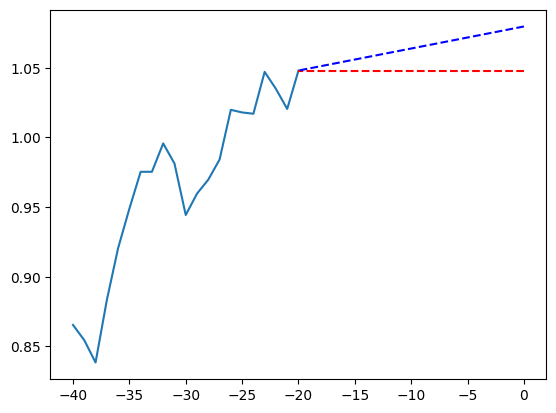

In [ ]:
# Function to convert a categorical prediction into an assumed price
def predict(row):
    last_price = row["last"]
    pred_class = row["class"]
    p = 0.02 if pred_class == "up" else -0.02 if pred_class == "down" else 0
    return last_price + p * abs(last_price)
pred_y = pd.DataFrame({"class": model.predict(test_X), "last": test_X[last_col]}).apply(predict, axis=1)
real_y = pd.DataFrame({"class": test_y, "last": test_X[last_col]}).apply(predict, axis=1)
idx = pred_y.sample(n=1).index[0]

pairs = [(val, -step) for (val, step) in zip(test_X.loc[idx], steps)]
pairs.sort(key=lambda p: p[1])

x = [t for (_, t) in pairs]
y = [v for (v, _) in pairs]

(last_y, last_x) = pairs[-1]

plt.figure()
plt.plot(x, y)
plt.plot([0, last_x], [pred_y[idx], last_y], 'r--')
plt.plot([0, last_x], [data.loc[idx]["open"], last_y], 'b--')
plt.show()
# wow, it's Not Great(tm)